```
Copyright 2026 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
```

In [ ]:
import pandas as pd

# view all the columns
pd.set_option('display.max_columns', None)

# To download the data, follow instructions at https://doi.org/10.7910/DVN/0SGZFF.
survey_and_browser_attrs_fpath = './survey-and-browser-attributes-data.txt'

In [ ]:
stable_ba_names = [
    'User agent', 'Languages', # Can be collected passively via HTTP headers
    'Timezone', 'Screen resolution',
    'Color depth', 'Platform', 'Touch points',
    'Hardware concurrency', 'Device memory',
    'WebGL Vendor', 'WebGL Unmasked Vendor',
    'WebGL Renderer', 'WebGL Unmasked Renderer',
]
# Replace nan values with the empty string
sba_df = pd.read_csv(survey_and_browser_attrs_fpath, usecols=['ResponseId']+stable_ba_names)
sba_df = sba_df.set_index('ResponseId').fillna('')
N = len(sba_df)
N

8400

In [ ]:
def get_unhashed_fingerprint(user_data):
  return ':'.join(pd.Series(user_data).values.astype(str).tolist())

def get_fingerprint(user_data):
  return hash(get_unhashed_fingerprint(user_data))

sba_df['Fingerprint'] = sba_df[stable_ba_names].apply(get_fingerprint, axis=1)

In [ ]:
from scipy.stats import entropy

# shannon entropy (standard measurement)
def get_shannon_entropy(values):
  pk = pd.Series(values).value_counts()/len(values) # distribution probabilities
  assert(pk.sum().round(10) == 1)
  H = entropy(pk, base=2) # unit is bits
  return H

def get_normalized_shannon_entropy(values):
  """Returns value H(X)/H_N where H_N represents worst case where all values are unique."""
  H_N = get_shannon_entropy(list(range(len(values))))
  return get_shannon_entropy(values)/H_N

def get_reid_score(values):
  pk = values.value_counts()/len(values) # distribution probabilities
  assert(pk.sum().round(10) == 1)
  return pk.pow(2).sum()

def get_tsallis_entropy(values):
  return 1 - get_reid_score(values)

def get_frac_unique(values):
  value_counts = values.value_counts()
  return round((value_counts == 1).sum()/len(values), 4)


test_attr = 'User agent'
values = sba_df[test_attr]
print('%0.3f = Shannon entropy for %s' % (get_shannon_entropy(values), test_attr))
print('%0.3f = Normalized Shannon entropy for %s' % (get_normalized_shannon_entropy(values), test_attr))

4.613 = Shannon entropy for User agent
0.354 = Normalized Shannon entropy for User agent


In [ ]:
attributes = stable_ba_names + ['Fingerprint']
df = pd.DataFrame({
    'Attribute': attributes,
    'Distinct values': [sba_df[a].nunique() for a in attributes],
    '% Unique': [round(100*(sba_df[a].value_counts() == 1).sum()/N, 1) for a in attributes],
    'Shannon entropy': [round(get_shannon_entropy(sba_df[a]),3) for a in attributes],
    'Norm. entropy': [round(get_normalized_shannon_entropy(sba_df[a]),3) for a in attributes],
    'Tsallis entropy': [round(get_tsallis_entropy(sba_df[a]),3) for a in attributes],
    'Example value (most frequent)': [sba_df[a].mode()[0] for a in attributes],
})
df.set_index('Attribute')

,Distinct values,% Unique,Shannon entropy,Norm. entropy,Tsallis entropy,Example value (most frequent)
Attribute,,,,,,
User agent,434,2.8,4.613,0.354,0.859,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
Languages,264,2.4,1.730,0.133,0.484,"en-US,en"
Timezone,49,0.2,2.064,0.158,0.674,America/New_York
Screen resolution,572,4.5,5.510,0.423,0.940,"[1920,1080]"
Color depth,3,0.0,0.616,0.047,0.204,24
Platform,12,0.0,2.114,0.162,0.688,Win32
Touch points,11,0.0,1.463,0.112,0.581,0
Hardware concurrency,24,0.1,2.340,0.180,0.727,4.0
Device memory,7,0.0,1.611,0.124,0.610,8.0


In [ ]:
!pip install adjustText

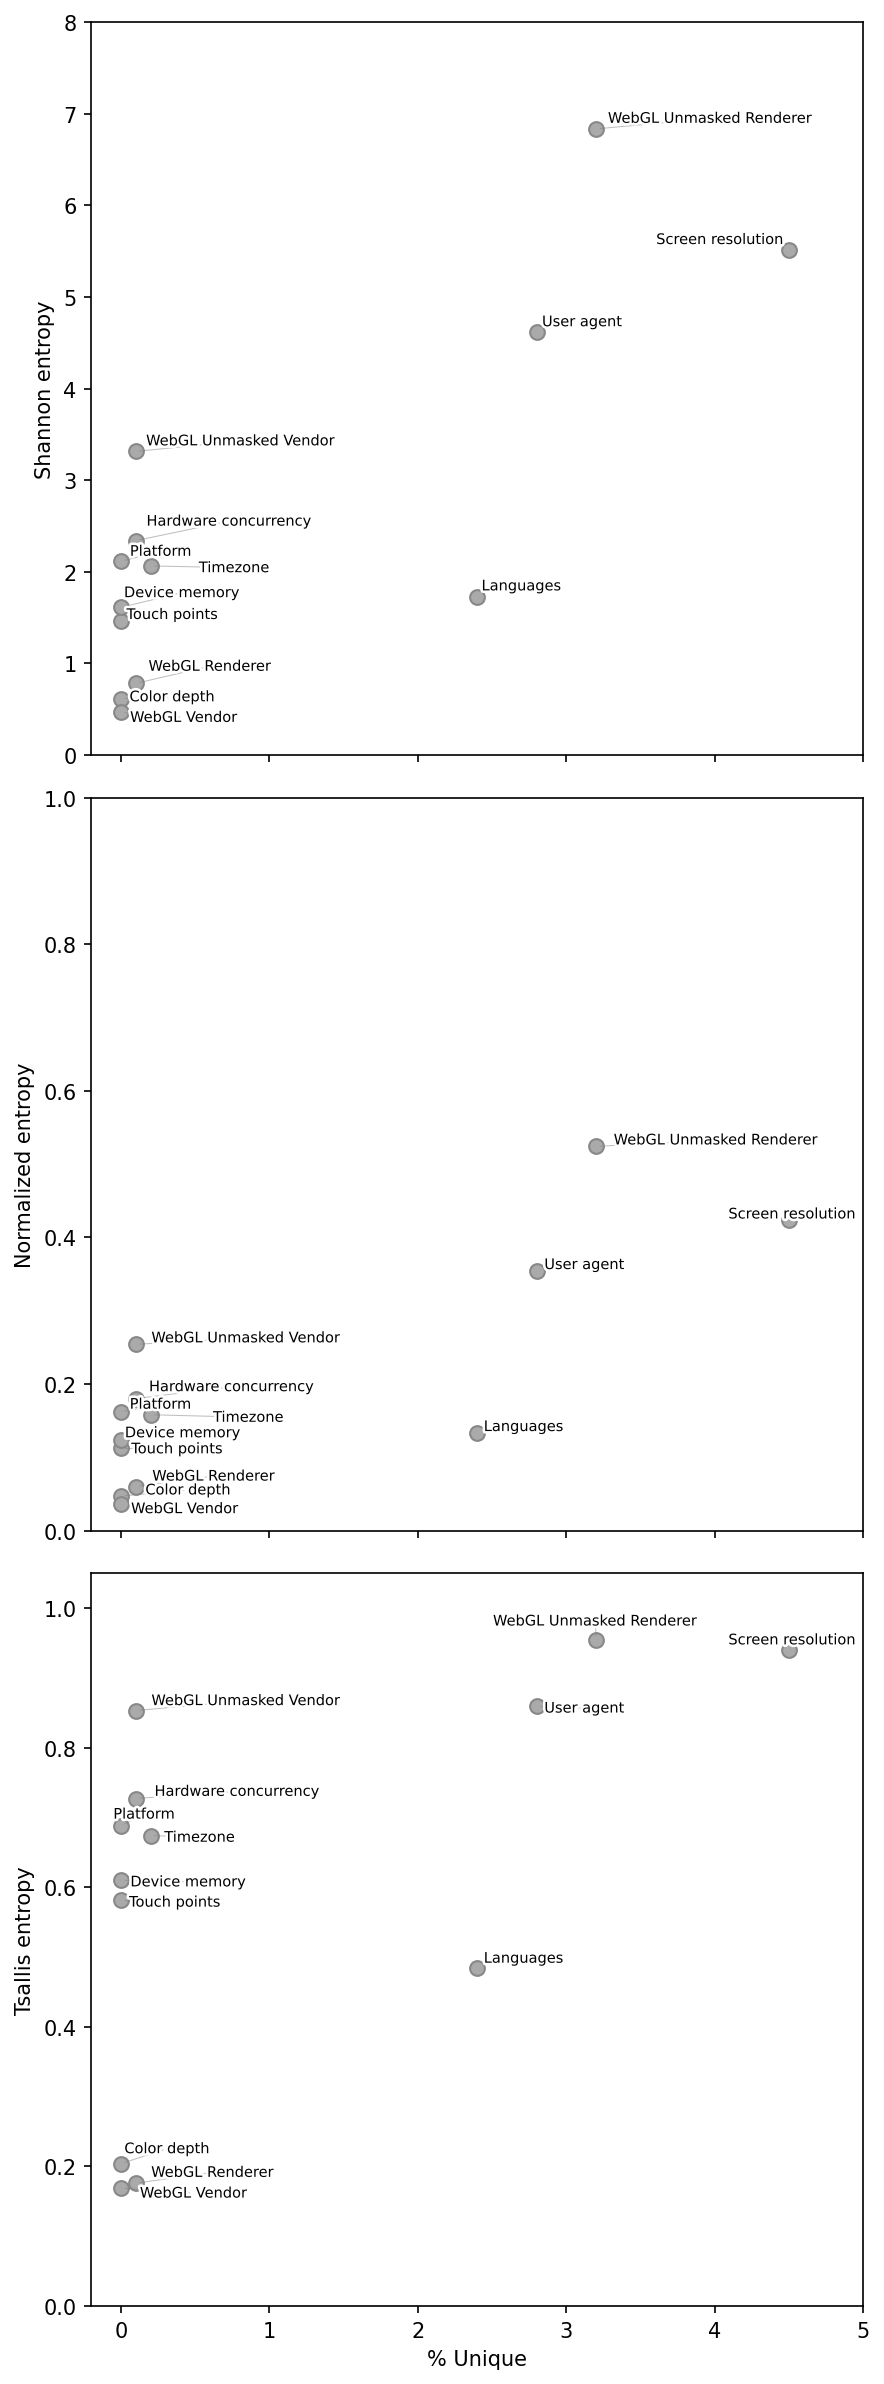

In [ ]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import matplotlib.patheffects as pe

# Filter out Fingerprint for clearer attribute comparison
df2 = df[df.Attribute != 'Fingerprint'].copy()

# Define the metrics and their specific vertical axis properties
metrics = [
    ('Shannon entropy', 'Shannon entropy', (0, 8)),
    ('Norm. entropy', 'Normalized entropy', (0, 1)),
    ('Tsallis entropy', 'Tsallis entropy', (0, 1.05)),
]

# Create a figure with 3 rows and 1 column
fig, axes = plt.subplots(3, 1, figsize=(6, 16), dpi=150, sharex=True)

for i, (col_name, y_label, y_limit) in enumerate(metrics):
    ax = axes[i]

    # 1. Create the scatter plot on the specific axis
    scatter = ax.scatter(
        df2['% Unique'],
        df2[col_name],
        c='#aaa',
        s=50,
        edgecolor='#888',
        zorder=3
    )

    # 2. Prepare labels with a bbox to fix the arrow overlap
    texts = [
        ax.text(
            row['% Unique'],
            row[col_name],
            row['Attribute'],
            fontsize=7,
            zorder=4,
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')]
        )
        for _, row in df2.iterrows()]

    # 3. Adjust text positions for this specific subplot
    adjust_text(
        texts,
        x=df2['% Unique'].values,
        y=df2[col_name].values,
        ax=ax,
        expand_text=(1.5, 1.6),
        expand_points=(1.5, 1.5),
        arrowprops=dict(
            arrowstyle='-',
            color='gray',
            lw=0.5,
            alpha=0.5,
            zorder=1
        )
    )

    # 4. Set labels and limits for the subplot
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_ylim(y_limit)
    ax.set_xlim(-0.2, 5)

# Set common X-label on the bottom subplot
axes[-1].set_xlabel('% Unique', fontsize=10)

plt.tight_layout()
plt.show()
